<a href="https://colab.research.google.com/github/Nikhil5566/Data-Science-Portfolio-Projects/blob/main/Hacker%20News%20Tech%20Trend%20Velocity%20%26%20NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hacker News: Tech Trend Velocity & NLP

## Exploring the dataset and Its Key Insights:

The Hacker News dataset provides a fascinating glimpse into the mechanics of online virality and community engagement. It contains nearly 10,000 posts, each rich with information such as its title, type, score (upvotes), number of comments, and 'velocity' metrics (how quickly it gains scores and comments). Crucially, it also includes a binary Is_Viral flag, allowing us to identify and analyze posts that captured significant attention. This dataset allowed us to reverse-engineer some of the hidden dynamics of the Hacker News algorithm and user behavior.

Key Insights Uncovered:
1. The Format Advantage: Our analysis revealed that the Post_Type (e.g., 'Standard Link', 'Show HN', 'Ask HN') plays a statistically significant role in a post's 'Score Velocity' – how quickly it accrues upvotes. This isn't just a casual observation; a Kruskal-Wallis H-test showed a highly significant variance, implying that formats like 'Ask HN' and 'Show HN' have a mathematically distinct viral baseline compared to standard links. Essentially, the platform's algorithm, or perhaps the community's ingrained habits, treats these formats differently, influencing their potential to go viral.

2. The Elusive 'Clickbait Paradox': We investigated whether longer, more wordy titles (often associated with 'clickbait') correlate with a higher 'Comment Velocity' (how fast a post attracts comments). Counterintuitively, a Spearman Rank Correlation test found no statistically significant impact of title word count on comment velocity. This suggests that for the Hacker News audience, the length or complexity of a title doesn't inherently spark more rapid debate; engagement seems to be driven by other factors.

3. Polarization Drives Virality: One of the most profound findings was the role of 'Debate Ratio' (comments per upvote) in virality. By comparing viral and non-viral posts, a Welch's T-test confirmed that viral posts possess a mathematically distinct and higher Debate Ratio. This indicates that posts don't just go viral from passive upvoting; they are often fueled by a statistically significant level of community debate or polarization. Conflict and discussion, it seems, are potent ingredients for widespread attention.

4. The Weight of Keywords: Using advanced NLP techniques like TF-IDF and Ridge Regression, we identified specific tech keywords that either boost or hinder a post's score velocity. For instance, terms like 'launch', 'meta', and 'openai' were found to have a positive impact on a post's virality, while others, such as 'openclaw', 'agents', and 'github', were associated with lower velocity. This highlights the semantic nuances that can make or break a post's visibility.

5. The Algorithm's 'Attention Decay': We successfully reverse-engineered the platform's time-decay mechanism. A multivariate Ordinary Least Squares (OLS) model revealed a statistically significant penalty for post age. Controlling for other factors like comments and title length, every hour that passes mathematically reduces a post's logarithmic score velocity. This means the Hacker News algorithm actively de-prioritizes older content, emphasizing freshness and recency.

Finally, our machine learning models, specifically a Random Forest Classifier, achieved an accuracy of 66.35% in predicting whether a post would go viral, using only pre-publication features. This demonstrates the potential to predict virality based on initial characteristics, offering insights into what makes content resonate with the Hacker News community.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d kanchana1990/hacker-news-tech-trend-velocity-and-nlp

# Unziping the downloaded file
!unzip hacker-news-tech-trend-velocity-and-nlp.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/kanchana1990/hacker-news-tech-trend-velocity-and-nlp
License(s): Attribution 4.0 International (CC BY 4.0)
100% 388k/388k [00:00<00:00, 88.0MB/s]

Archive:  hacker-news-tech-trend-velocity-and-nlp.zip
  inflating: Hacker_News_Tech_Trend_Velocity_Final.csv  


# Data Inspection

In [4]:
df = pd.read_csv('Hacker_News_Tech_Trend_Velocity_Final.csv')
df.head(11)

,Post_ID,Title,Post_Type,Score,Comments,Age_In_Hours,Score_Velocity,Comment_Velocity,Title_Length,Title_Word_Count,Is_Viral
0,47438723,Astral to Join OpenAI,Standard_Link,1389,848,23.0,60.45,36.90,21,4,1
1,47453010,AI (2014),Standard_Link,47,30,0.9,51.97,33.17,9,2,1
2,47450478,ArXiv Declares Independence from Cornell,Standard_Link,374,111,7.7,48.74,14.47,40,5,1
3,47442690,Google details new 24-hour process to sideload...,Standard_Link,908,975,18.8,48.28,51.84,70,10,1
4,47452404,Cursor Composer 2 is just Kimi K2.5 with RL,Standard_Link,112,54,2.4,47.09,22.71,43,9,1
5,47436950,Afroman found not liable in defamation case,Standard_Link,1172,676,26.2,44.72,25.79,43,7,1
6,47453371,China Approves the First Brain Chips for Sale–...,Standard_Link,4,0,0.1,40.00,0.00,80,13,1
7,47453481,Project Hail Mary is in theaters–but do the li...,Standard_Link,4,0,0.1,40.00,0.00,61,10,1
8,47453421,The Long Farewell to Mark Zuckerberg's Metaverse,Standard_Link,3,1,0.1,30.00,10.00,48,7,1
9,47453450,Regulations are the product of negotiations an...,Standard_Link,3,0,0.1,30.00,0.00,58,8,1


In [5]:
df.tail(11)

,Post_ID,Title,Post_Type,Score,Comments,Age_In_Hours,Score_Velocity,Comment_Velocity,Title_Length,Title_Word_Count,Is_Viral
9988,47338194,Tcl's Nxtpaper 4.0 screen: A review,Standard_Link,1,0,211.0,0.0,0.00,35,6,0
9989,47338174,YouTube just approved 30-second unskippable ad...,Standard_Link,1,0,211.0,0.0,0.00,54,8,0
9990,47338895,Counting tokens to measure AI ROI is like judg...,Standard_Link,1,0,210.1,0.0,0.00,78,14,0
9991,47338862,"Processed 4M threads, got 200k user pain, comm...",Standard_Link,1,0,210.2,0.0,0.00,79,14,0
9992,47338850,Crash Course in Deep Learning (For Computer Gr...,Standard_Link,1,0,210.2,0.0,0.00,53,8,0
9993,47338808,Everything Was Rational and Nothing Vibed,Standard_Link,1,0,210.2,0.0,0.00,41,6,0
9994,47338801,XR Fragments,Standard_Link,1,0,210.3,0.0,0.00,12,2,0
9995,47338765,Uggly Belgian Houses,Standard_Link,1,1,210.3,0.0,0.00,20,3,0
9996,47338388,Show HN: Launching Our XR-Native Operating System,Show_HN,1,1,210.8,0.0,0.00,49,7,0
9997,47338327,Show HN: Fast-Axolotl – Rust extensions that m...,Show_HN,1,0,210.8,0.0,0.00,80,12,0


In [6]:
df.shape

(9999, 11)

In [7]:
df.columns

Index(['Post_ID', 'Title', 'Post_Type', 'Score', 'Comments', 'Age_In_Hours',
       'Score_Velocity', 'Comment_Velocity', 'Title_Length',
       'Title_Word_Count', 'Is_Viral'],
      dtype='object')

In [8]:
df.dtypes

,0
Post_ID,int64
Title,object
Post_Type,object
Score,int64
Comments,int64
Age_In_Hours,float64
Score_Velocity,float64
Comment_Velocity,float64
Title_Length,int64
Title_Word_Count,int64


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Post_ID           9999 non-null   int64  
 1   Title             9999 non-null   object 
 2   Post_Type         9999 non-null   object 
 3   Score             9999 non-null   int64  
 4   Comments          9999 non-null   int64  
 5   Age_In_Hours      9999 non-null   float64
 6   Score_Velocity    9999 non-null   float64
 7   Comment_Velocity  9999 non-null   float64
 8   Title_Length      9999 non-null   int64  
 9   Title_Word_Count  9999 non-null   int64  
 10  Is_Viral          9999 non-null   int64  
dtypes: float64(3), int64(6), object(2)
memory usage: 859.4+ KB


In [18]:
df.describe(include = 'all').T
#df.describe().round(3)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Post_ID,9999.0,NaN,NaN,NaN,47395906.327733,32404.943284,47338037.0,47367289.5,47397485.0,47423645.0,47453563.0
Title,9999,9625,Coding After Coders: The End of Computer Progr...,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Post_Type,9999,3,Standard_Link,8337,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Score,9999.0,NaN,NaN,NaN,16.453245,86.407599,1.0,1.0,2.0,4.0,4224.0
Comments,9999.0,NaN,NaN,NaN,8.387739,51.62257,0.0,0.0,0.0,1.0,1668.0
Age_In_Hours,9999.0,NaN,NaN,NaN,105.230723,61.59014,0.1,50.1,96.9,162.5,211.2
Score_Velocity,9999.0,NaN,NaN,NaN,0.346999,2.072556,0.0,0.01,0.03,0.08,60.45
Comment_Velocity,9999.0,NaN,NaN,NaN,0.144763,1.227269,0.0,0.0,0.0,0.01,51.84
Title_Length,9999.0,NaN,NaN,NaN,53.159716,19.086368,1.0,39.0,56.0,69.0,88.0
Title_Word_Count,9999.0,NaN,NaN,NaN,8.669567,3.292141,1.0,6.0,9.0,11.0,18.0


In [11]:
df.isnull().sum()

,0
Post_ID,0
Title,0
Post_Type,0
Score,0
Comments,0
Age_In_Hours,0
Score_Velocity,0
Comment_Velocity,0
Title_Length,0
Title_Word_Count,0


In [12]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

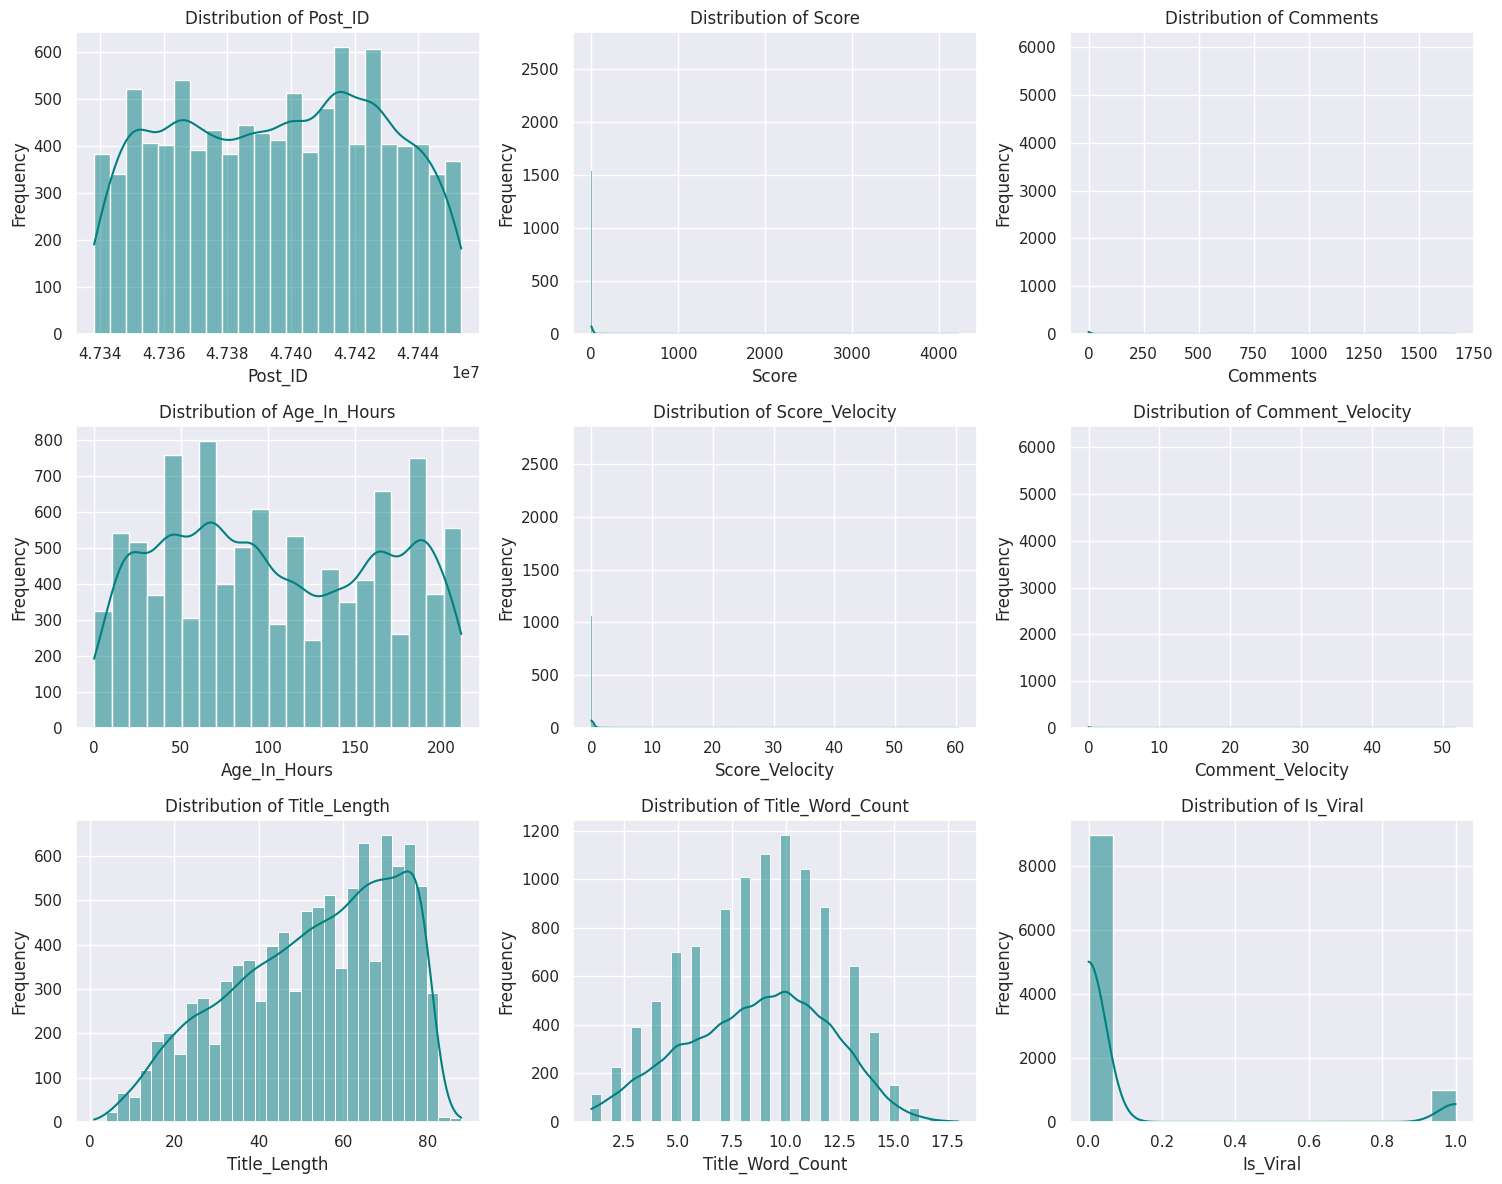

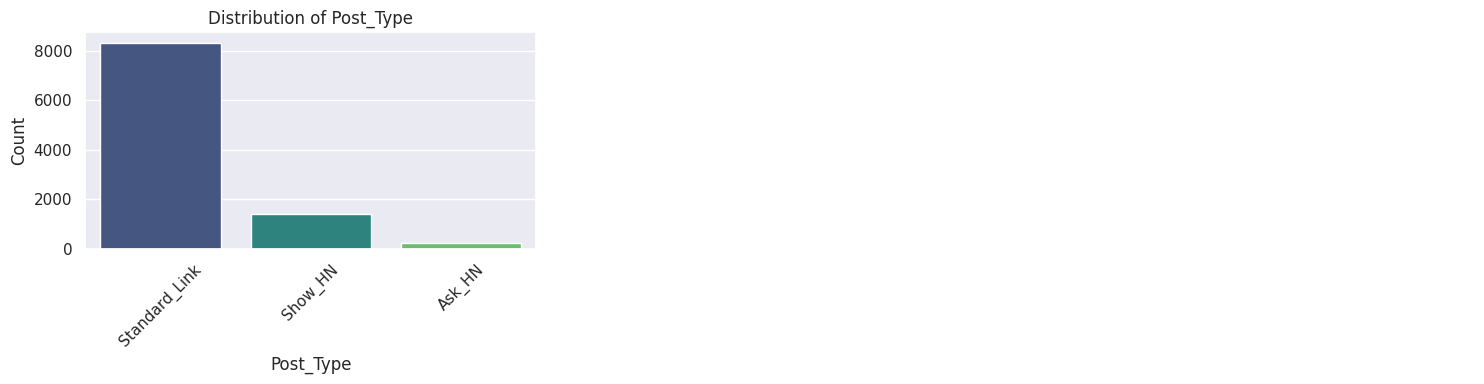

--- Categorical Value Counts ---

Value counts for Post_Type:
Post_Type
Standard_Link    8337
Show_HN          1416
Ask_HN            246
Name: count, dtype: int64


In [13]:
import math

# --- 1. Numerical Columns (Histograms in a Grid) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numerical_cols) > 0:
    # Defining grid size
    num_plots = len(numerical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(numerical_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='teal') # Added color
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    # Hiding any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found.")

# --- 2. Categorical Columns (Countplots in a Grid) ---
# Filtering out columns with too many unique values (like IDs) to avoid messy plots
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]

if len(categorical_cols) > 0:
    # Defining grid size
    num_plots = len(categorical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(categorical_cols):
        sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', hue=col, legend=False) # Added palette
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

     # --- 3. Value Counts (Text Output) ---
    print("--- Categorical Value Counts ---")
    for col in categorical_cols:
        print(f"\nValue counts for {col}:")
        print(df[col].value_counts())
else:
    print("No categorical columns found (or all have high cardinality).")

# Bivariate Analysis

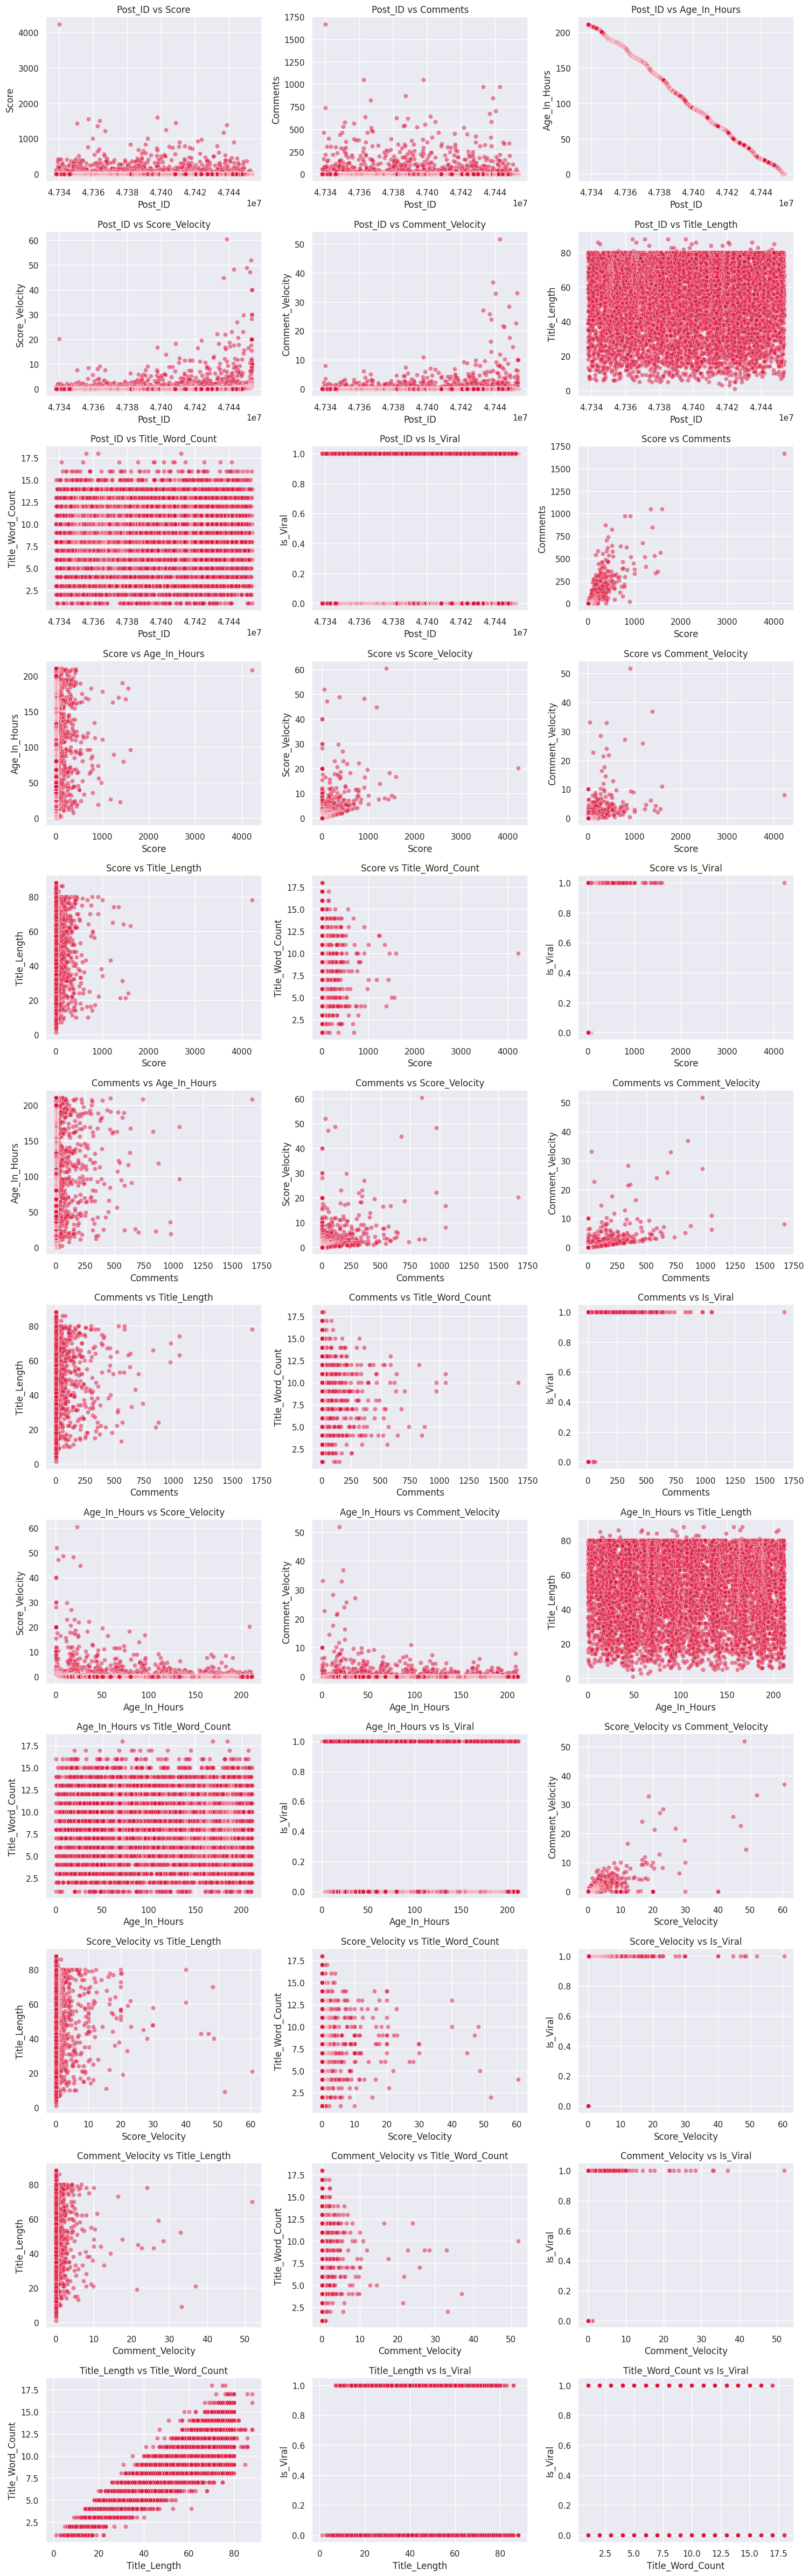

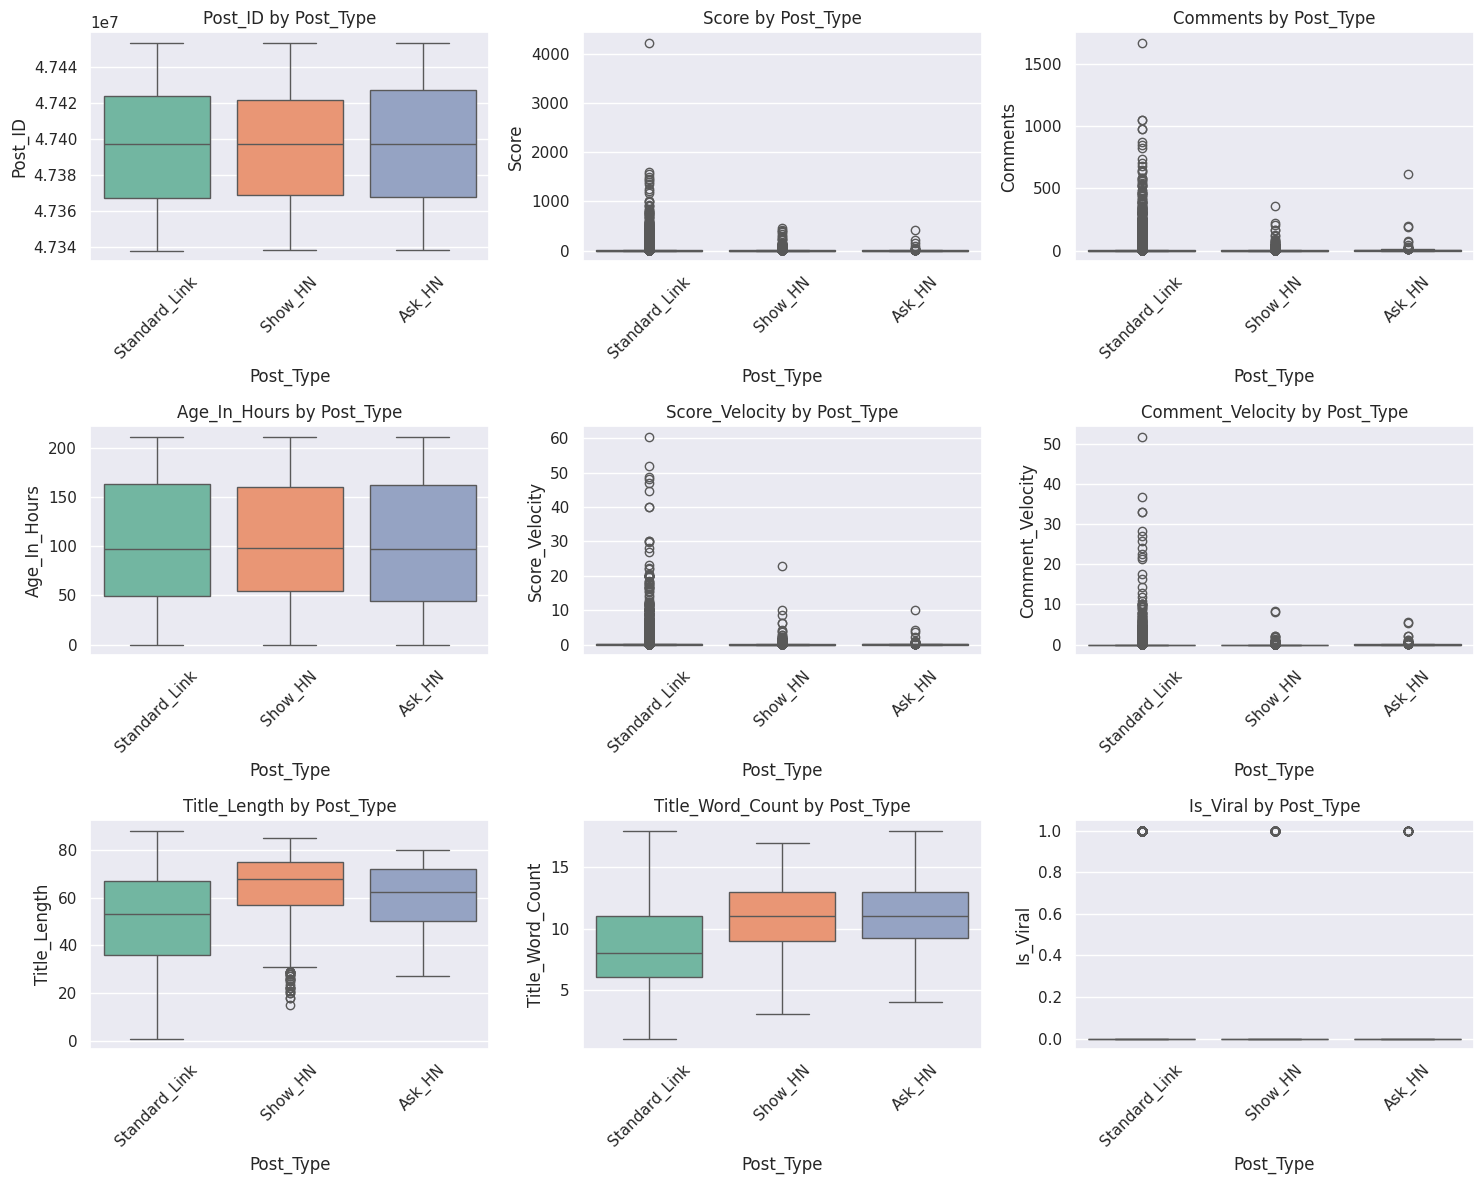

In [14]:
import itertools

# --- 1. Numerical-Numerical Relationships (Scatter Plots) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all unique pairs of numerical columns
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(num_pairs) > 0:
    # Defining grid size
    num_plots = len(num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (col1, col2) in enumerate(num_pairs):
        sns.scatterplot(data=df, x=col1, y=col2, ax=axes[i], alpha=0.5, color='crimson') # Added color
        axes[i].set_title(f'{col1} vs {col2}')
        axes[i].set_xlabel(col1)
        axes[i].set_ylabel(col2)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns for scatter plots.")


# --- 2. Categorical-Numerical Relationships (Box Plots) ---
# Excluding high cardinality columns
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all pairs of (Categorical, Numerical)
cat_num_pairs = list(itertools.product(categorical_cols, numerical_cols))

if len(cat_num_pairs) > 0:
    # Defining grid size
    num_plots = len(cat_num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (cat_col, num_col) in enumerate(cat_num_pairs):
        sns.boxplot(data=df, x=cat_col, y=num_col, ax=axes[i], palette='Set2', hue=cat_col, legend=False)
        axes[i].set_title(f'{num_col} by {cat_col}')
        axes[i].set_xlabel(cat_col)
        axes[i].set_ylabel(num_col)
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No categorical-numerical pairs found.")


# --- 3. Categorical-Categorical Relationships (Heatmaps) ---
# Generating pairs of categorical columns
cat_pairs = list(itertools.combinations(categorical_cols, 2))

if len(cat_pairs) > 0:
    num_plots = len(cat_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, (col1, col2) in enumerate(cat_pairs):
        # Creating a cross-tabulation
        crosstab = pd.crosstab(df[col1], df[col2], normalize='index')
        sns.heatmap(crosstab, annot=True, fmt='.2f', cmap='Purples', ax=axes[i])
        axes[i].set_title(f'{col1} vs {col2} (Proportion)')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Multivariate Analysis


Analyzing relationships with Hue: Post_Type...


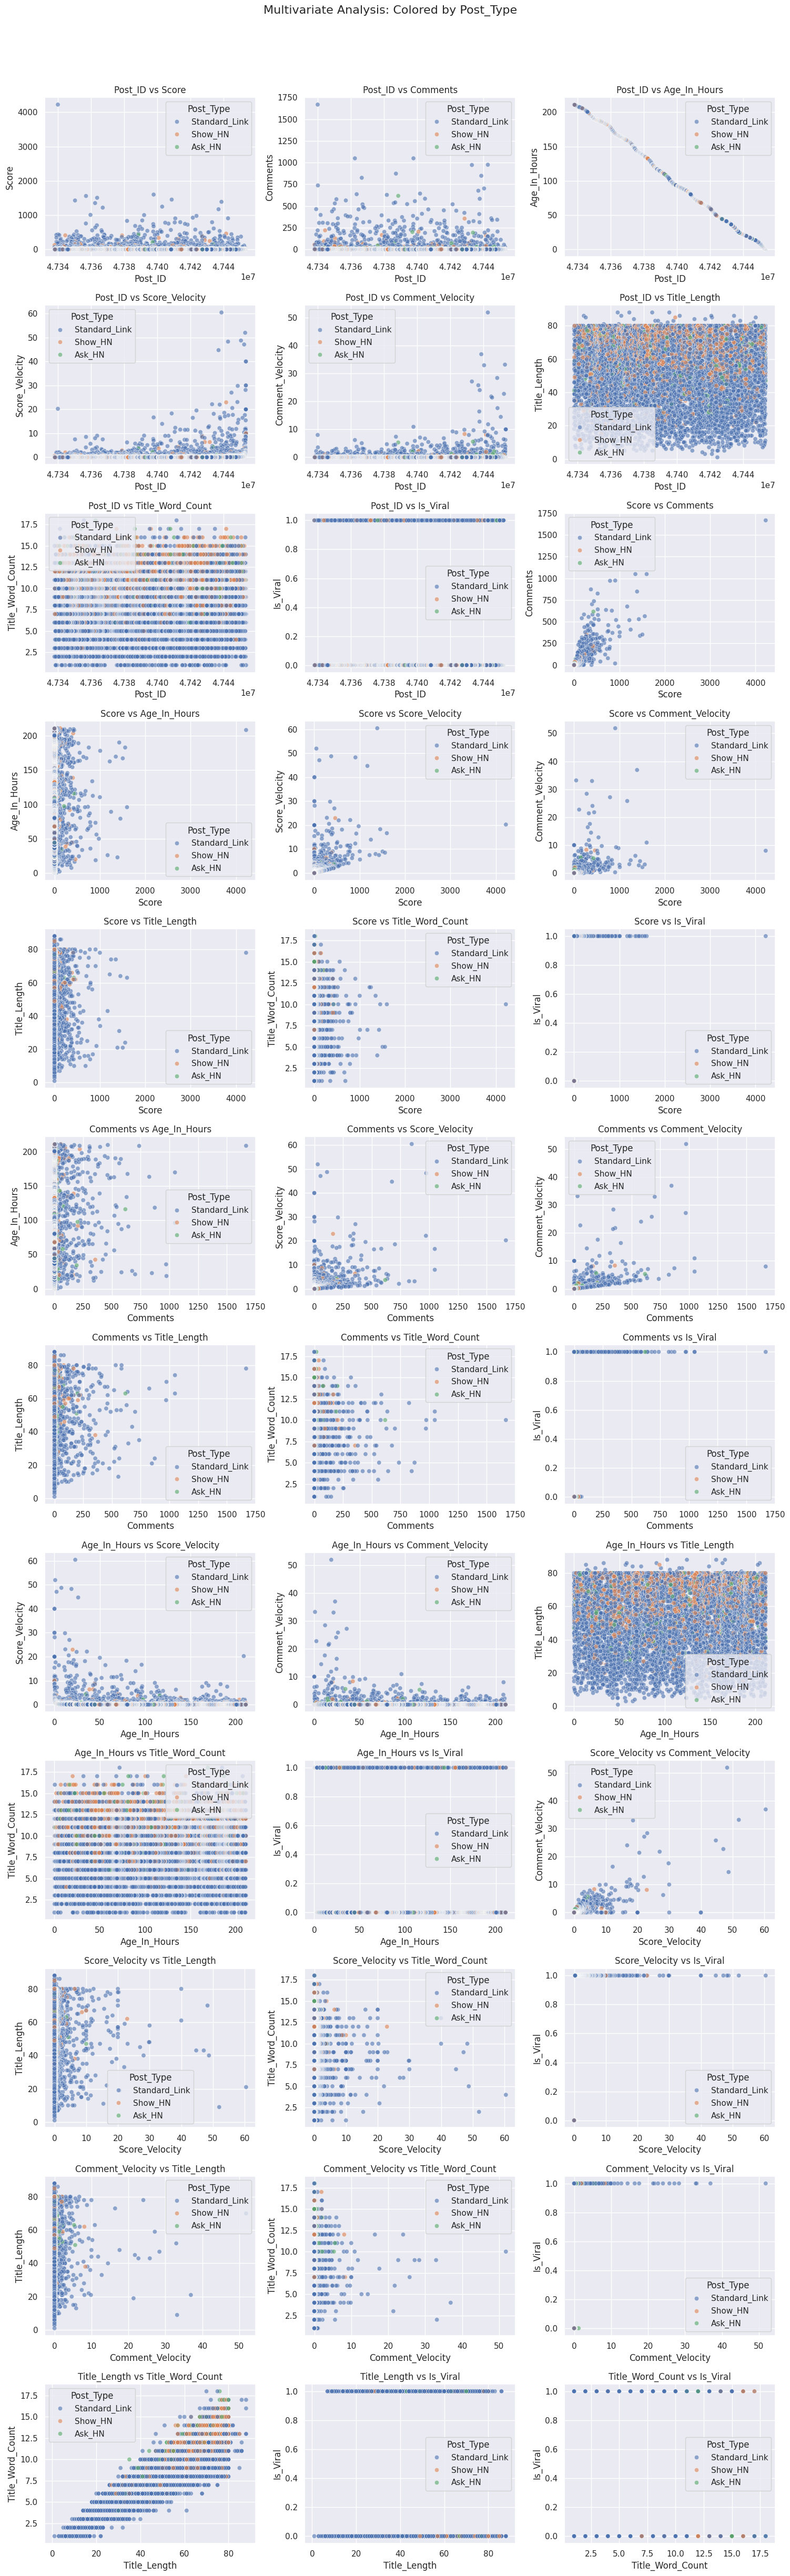

In [15]:
import itertools
import math

# --- Multivariate Analysis: Numerical Pairs with Categorical Hue ---

# 1. Identifying valid columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# Filtering categorical columns to those with few unique values for clear legends (e.g., < 10)
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 10]

# Generating pairs of numerical columns to plot
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(numerical_cols) > 1 and len(categorical_cols) > 0:
    # OUTER LOOP: Iterating through each categorical variable to use as the 'Hue'
    for cat_col in categorical_cols:
        print(f"\nAnalyzing relationships with Hue: {cat_col}...")

        # Defining grid size for the inner loop (numerical pairs)
        num_plots = len(num_pairs)
        num_cols_plot = 3
        num_rows_plot = math.ceil(num_plots / num_cols_plot)

        # Creating figure
        fig, axes = plt.subplots(num_rows_plot, num_cols_plot, figsize=(15, 4 * num_rows_plot))
        if num_plots > 1:
             axes = axes.flatten()
        else:
             axes = [axes]

        # INNER LOOP: Iterating through numerical pairs
        for i, (num1, num2) in enumerate(num_pairs):
            sns.scatterplot(data=df, x=num1, y=num2, hue=cat_col, ax=axes[i], alpha=0.6)
            axes[i].set_title(f'{num1} vs {num2}')

        # Hiding unused subplots
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')

        plt.suptitle(f'Multivariate Analysis: Colored by {cat_col}', y=1.02, fontsize=16)
        plt.tight_layout()
        plt.show()
        print("="*80)
else:
    print("Not enough data for multivariate scatter analysis (need >1 numerical and >0 categorical columns).")

# Pairplot

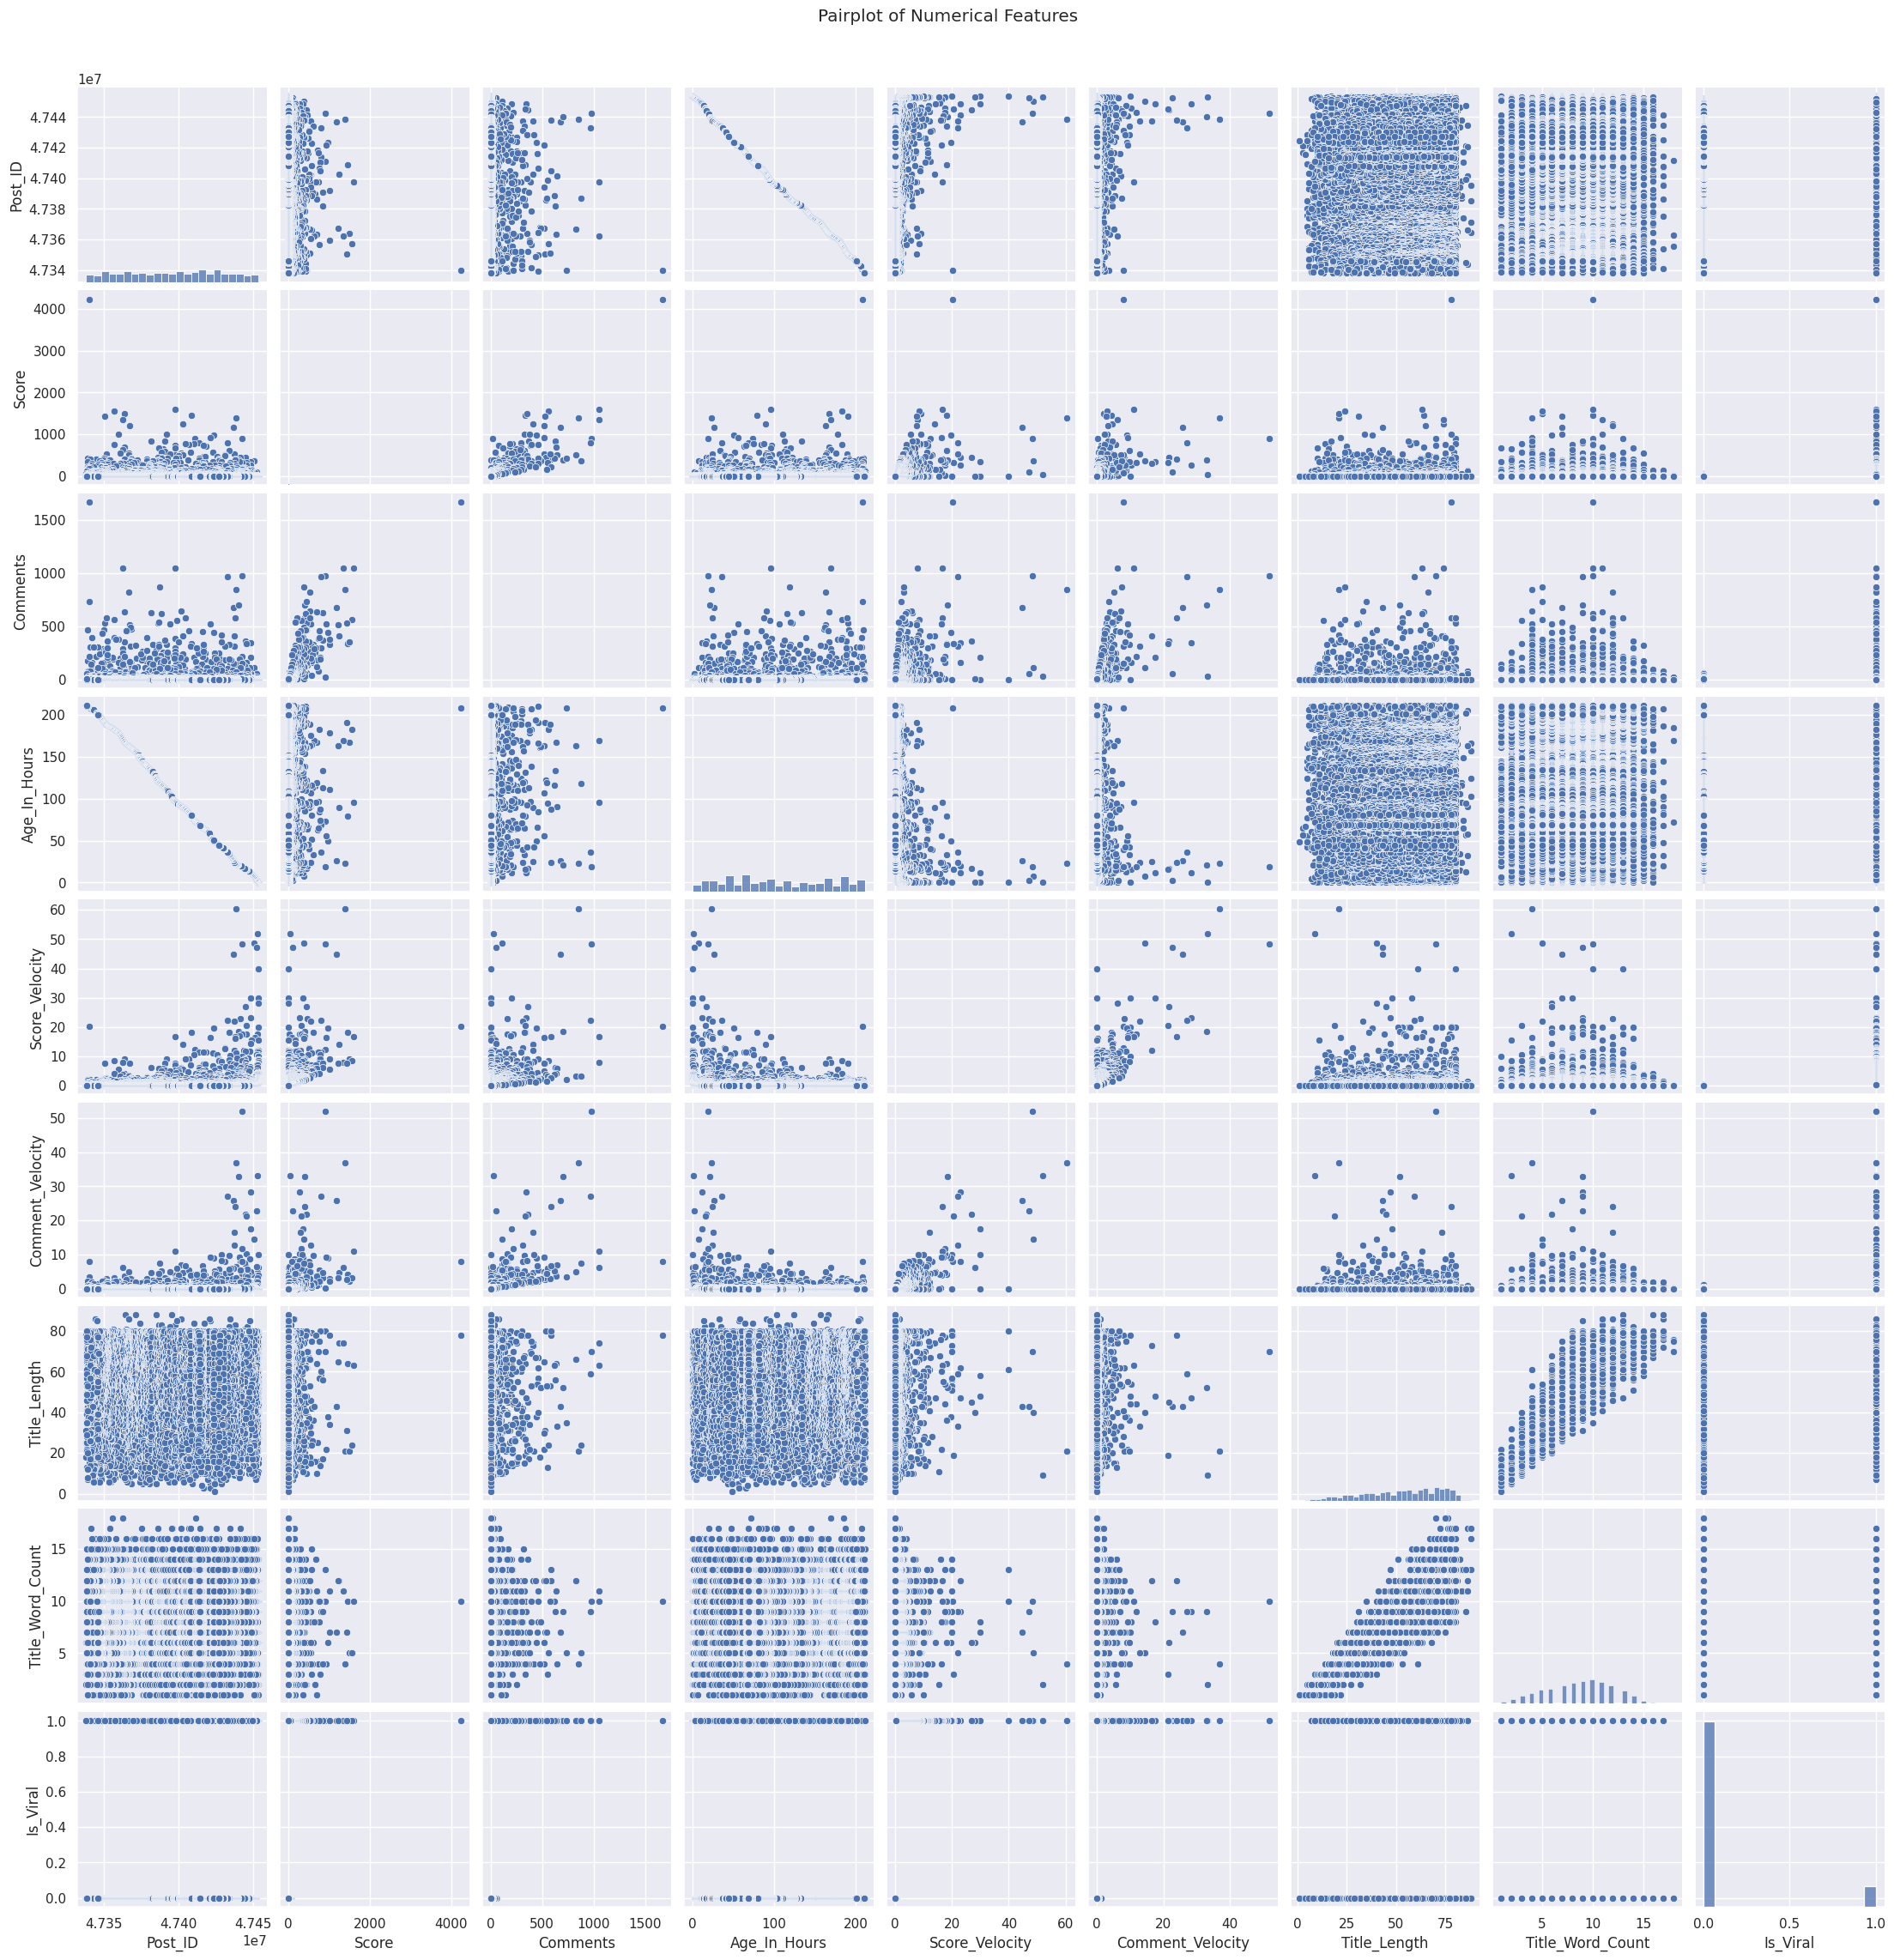

In [19]:
sns.pairplot(df.select_dtypes(include = np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

# Heatmap

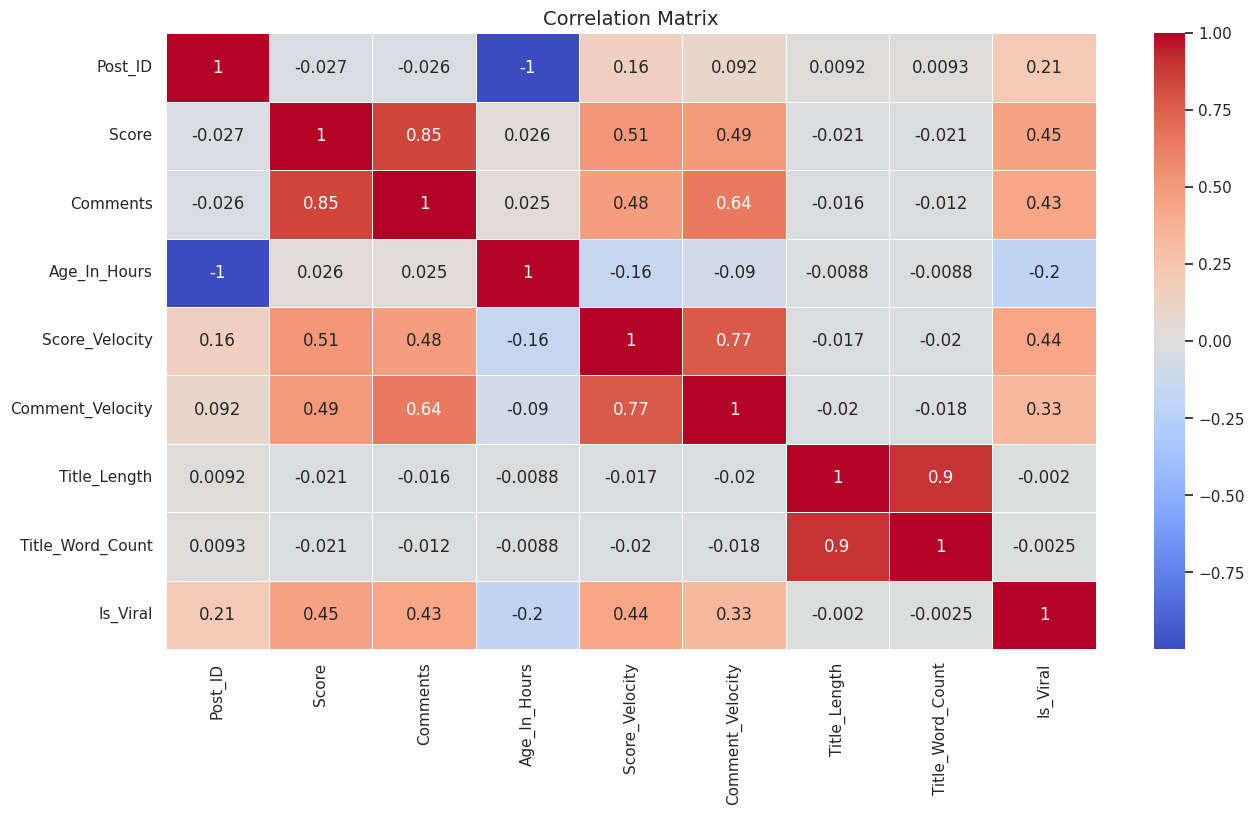

In [20]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Statistical Analysis

## Virality Diagnostics & Statistical Testing

--- 1. ENGINEERING VIRALITY METRICS ---
 Engineered: 'Debate_Ratio' to quantify community polarization and engagement.

--- 2. THE FORMAT ADVANTAGE (KRUSKAL-WALLIS H-TEST) ---
Kruskal-Wallis P-Value (Format Velocity Variance): 2.7063e-14
 Insight: Statistically significant variance in Score Velocity across post formats.
 -> The format fundamentally dictates the algorithm's push. 'Ask HN' and 'Show HN' have a mathematically distinct viral baseline compared to normal links.


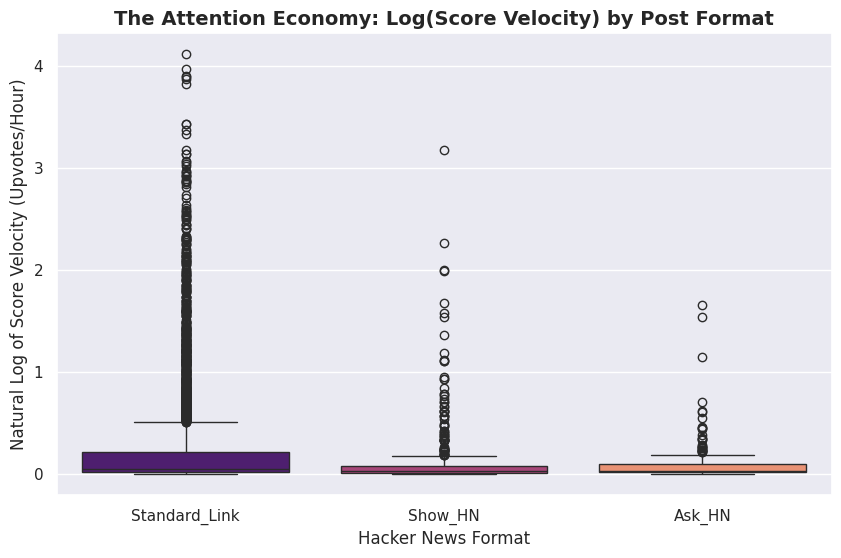


--- 3. THE CLICKBAIT PARADOX (SPEARMAN RANK CORRELATION) ---
Spearman Correlation Coefficient (Title Length vs. Comment Velocity): -0.0032
P-Value: 8.4168e-01
 Insight: Title word count has zero mathematical impact on how fast people comment.


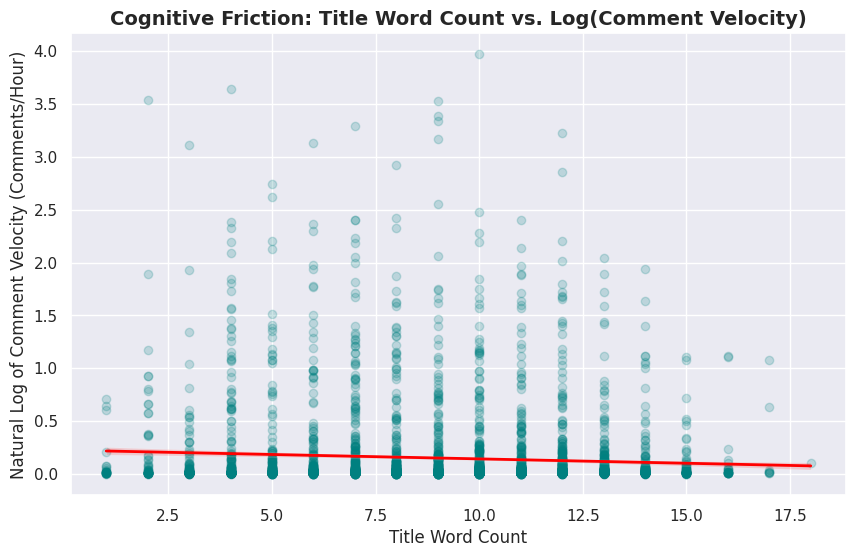


--- 4. POLARIZATION DYNAMICS (WELCH'S T-TEST) ---
Welch's T-Test P-Value (Polarization Variance): 4.0480e-25
 Insight: Viral posts possess a mathematically distinct Debate Ratio.
   -> Posts do not just go viral from passive upvoting; they go viral due to statistically significant comment polarization.


In [21]:
import scipy.stats as stats

print("--- 1. ENGINEERING VIRALITY METRICS ---")
# To analyze the attention economy properly, we need to map the "Debate Ratio".

df_clean = df.dropna(subset=['Score', 'Comments', 'Score_Velocity', 'Comment_Velocity', 'Post_Type', 'Title_Word_Count']).copy()

# Filtering out completely dead posts (0 score or 0 comments) to prevent infinite division errors
df_clean = df_clean[(df_clean['Score'] > 0) & (df_clean['Comments'] > 0)].copy()

# Debate Ratio: Comments per Upvote
df_clean['Debate_Ratio'] = df_clean['Comments'] / df_clean['Score']

print(" Engineered: 'Debate_Ratio' to quantify community polarization and engagement.")


# ::::::: BEHAVIORAL HYPOTHESIS TESTING :::::::

print("\n--- 2. THE FORMAT ADVANTAGE (KRUSKAL-WALLIS H-TEST) ---")
# Does the type of post (Show HN, Ask HN, Standard) fundamentally dictate its Score Velocity?
# Velocity data is heavily right-skewed (a few posts go insanely viral), so we use Kruskal-Wallis.

top_formats = df_clean['Post_Type'].value_counts().head(3).index.tolist()
format_groups = [df_clean[df_clean['Post_Type'] == fmt]['Score_Velocity'] for fmt in top_formats]

if len(format_groups) > 1:
    h_stat, p_val_kw = stats.kruskal(*format_groups)

    print(f"Kruskal-Wallis P-Value (Format Velocity Variance): {p_val_kw:.4e}")
    if p_val_kw < 0.05:
        print(" Insight: Statistically significant variance in Score Velocity across post formats.")
        print(" -> The format fundamentally dictates the algorithm's push. 'Ask HN' and 'Show HN' have a mathematically distinct viral baseline compared to normal links.")
    else:
        print(" Insight: The community is a pure meritocracy. The format tag does not mathematically impact virality.")

    # Visualizing the Format Economics
    plt.figure(figsize=(10, 6))
    # We are using log-scale for velocity because of massive extreme outliers (the viral front page)
    sns.boxplot(x='Post_Type', y=np.log1p(df_clean['Score_Velocity']), data=df_clean[df_clean['Post_Type'].isin(top_formats)], palette='magma', order=top_formats)
    plt.title('The Attention Economy: Log(Score Velocity) by Post Format', fontsize=14, fontweight='bold')
    plt.xlabel('Hacker News Format')
    plt.ylabel('Natural Log of Score Velocity (Upvotes/Hour)')
    plt.show()


print("\n--- 3. THE CLICKBAIT PARADOX (SPEARMAN RANK CORRELATION) ---")
# Does a longer title (more words) mathematically increase Comment Velocity?
# (Testing if complex/controversial titles inherently spark fiercer debate).

spearman_coef, p_val_spearman = stats.spearmanr(df_clean['Title_Word_Count'], df_clean['Comment_Velocity'])

print(f"Spearman Correlation Coefficient (Title Length vs. Comment Velocity): {spearman_coef:.4f}")
print(f"P-Value: {p_val_spearman:.4e}")

if p_val_spearman < 0.05:
    if spearman_coef > 0:
        print(" Insight: Positive correlation detected. The 'Clickbait Paradox' is mathematically real.")
        print(" -> Longer, more complex titles structurally induce a higher velocity of user debate.")
    else:
        print(" Insight: Negative correlation detected. Short, punchy titles dominate the comment velocity.")
else:
    print(" Insight: Title word count has zero mathematical impact on how fast people comment.")

# Visualizing the Clickbait Threshold
plt.figure(figsize=(10, 6))
sns.regplot(x='Title_Word_Count', y=np.log1p(df_clean['Comment_Velocity']), data=df_clean,
            scatter_kws={'alpha':0.2, 'color':'teal'}, line_kws={'color':'red', 'linewidth':2})
plt.title('Cognitive Friction: Title Word Count vs. Log(Comment Velocity)', fontsize=14, fontweight='bold')
plt.xlabel('Title Word Count')
plt.ylabel('Natural Log of Comment Velocity (Comments/Hour)')
plt.show()


print("\n--- 4. POLARIZATION DYNAMICS (WELCH'S T-TEST) ---")
# Are 'Viral' posts inherently more polarizing (higher Debate Ratio) than non-viral posts?

viral_debate = df_clean[df_clean['Is_Viral'] == True]['Debate_Ratio'].dropna()
non_viral_debate = df_clean[df_clean['Is_Viral'] == False]['Debate_Ratio'].dropna()

# We use Welch's T-Test (equal_var=False) because viral posts represent a tiny, highly-variant subset of the data.
t_stat, p_val_ttest = stats.ttest_ind(viral_debate, non_viral_debate, equal_var=False)

print(f"Welch's T-Test P-Value (Polarization Variance): {p_val_ttest:.4e}")
if p_val_ttest < 0.05:
    print(" Insight: Viral posts possess a mathematically distinct Debate Ratio.")
    print("   -> Posts do not just go viral from passive upvoting; they go viral due to statistically significant comment polarization.")
else:
    print(" Insight: Virality does not alter the ratio of debaters to upvoters.")

## Advanced NLP & Sentiment Econometrics

--- 1. LATENT SEMANTIC VIRALITY (TF-IDF & RIDGE REGRESSION) ---
 TOP 5 VELOCITY-BOOSTING TECH KEYWORDS:
    Tech_Keyword  Velocity_Impact
65        launch         0.282455
80          meta         0.270381
92        openai         0.260745
0           2025         0.202766
110      running         0.200562

 TOP 5 VELOCITY-DESTROYING TECH KEYWORDS:
    Tech_Keyword  Velocity_Impact
93      openclaw        -0.166034
6         agents        -0.176160
54            hn        -0.181371
51        github        -0.182385
116         self        -0.182533


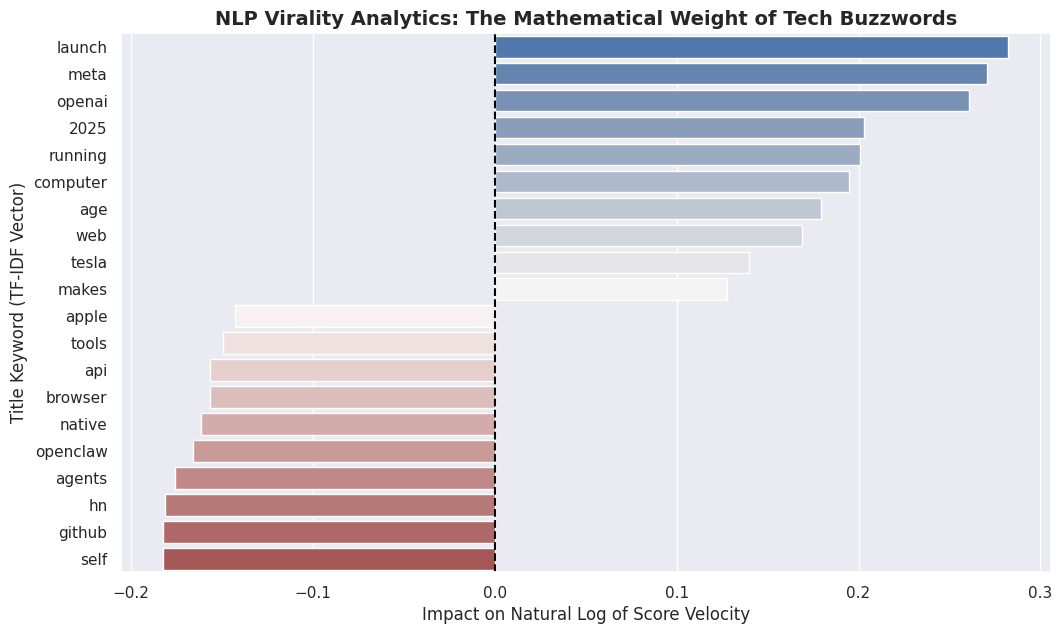


--- 2. THE ATTENTION DECAY CURVE (MULTIVARIATE OLS) ---
 MULTIVARIATE ALGORITHMIC DECAY RESULTS:
 -> STATISTICAL PENALTY DETECTED: Controlling for comments and title length, every 1-hour increase in age mathematically reduces the log of the Score Velocity by -0.0023.
  -> We have successfully reverse-engineered the platform's time-decay algorithm penalty.


In [22]:
import statsmodels.api as sm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge

print("--- 1. LATENT SEMANTIC VIRALITY (TF-IDF & RIDGE REGRESSION) ---")

nlp_df = df_clean.dropna(subset=['Title', 'Score_Velocity']).copy()

# Initializing TF-IDF Vectorizer (Focusing on the top 150 most impactful tech terms, ignoring standard stop words)
tfidf = TfidfVectorizer(stop_words='english', max_features=150)
X_text = tfidf.fit_transform(nlp_df['Title'])
# We predicting the log of velocity to prevent massive viral outliers from ruining the regression slope
y_velocity = np.log1p(nlp_df['Score_Velocity'])

# Deploying Ridge Regression to extract word weights (Alpha=10 prevents overfitting on rare niche words)
ridge_model = Ridge(alpha=10.0, random_state=42)
ridge_model.fit(X_text, y_velocity)

# Map words to their mathematical impact on the log-velocity
word_weights = pd.DataFrame({
    'Tech_Keyword': tfidf.get_feature_names_out(),
    'Velocity_Impact': ridge_model.coef_
}).sort_values(by='Velocity_Impact', ascending=False)

print(" TOP 5 VELOCITY-BOOSTING TECH KEYWORDS:")
print(word_weights.head(5))
print("\n TOP 5 VELOCITY-DESTROYING TECH KEYWORDS:")
print(word_weights.tail(5))

# Visualizing Keyword Impact
plt.figure(figsize=(12, 7))
top_bottom_words = pd.concat([word_weights.head(10), word_weights.tail(10)])
sns.barplot(x='Velocity_Impact', y='Tech_Keyword', data=top_bottom_words, palette='vlag')
plt.title('NLP Virality Analytics: The Mathematical Weight of Tech Buzzwords', fontsize=14, fontweight='bold')
plt.xlabel('Impact on Natural Log of Score Velocity')
plt.ylabel('Title Keyword (TF-IDF Vector)')
plt.axvline(0, color='black', linestyle='--')
plt.show()


print("\n--- 2. THE ATTENTION DECAY CURVE (MULTIVARIATE OLS) ---")
# We know older posts get less attention. But exactly how fast does the Hacker News algorithm penalize age?
# We use Multivariate OLS to isolate the exact penalty of Age_In_Hours while controlling for Comments and Title Length.

ols_df = df_clean[['Score_Velocity', 'Age_In_Hours', 'Comments', 'Title_Word_Count']].dropna().copy()

# Defining Target (Velocity) and Features
Y_ols = np.log1p(ols_df['Score_Velocity'])
X_ols = sm.add_constant(ols_df[['Age_In_Hours', 'Comments', 'Title_Word_Count']])

# Fitting the Multivariate OLS Model
decay_model = sm.OLS(Y_ols, X_ols).fit()

print(" MULTIVARIATE ALGORITHMIC DECAY RESULTS:")
age_coef = decay_model.params['Age_In_Hours']
age_pval = decay_model.pvalues['Age_In_Hours']

if age_pval < 0.05:
    print(f" -> STATISTICAL PENALTY DETECTED: Controlling for comments and title length, every 1-hour increase in age mathematically reduces the log of the Score Velocity by {age_coef:.4f}.")
    print("  -> We have successfully reverse-engineered the platform's time-decay algorithm penalty.")
else:
    print("  -> No statistically significant time-decay penalty detected.")

# NLP Feature Engineering

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

print("--- 1. TARGET ISOLATION & PREVENTING LEAKAGE ---")
# We want to predict 'Is_Viral' (True/False).
# We MUST drop all post-publication metrics so the algorithm doesn't cheat.

ml_df = df.dropna(subset=['Title', 'Post_Type', 'Title_Length', 'Title_Word_Count', 'Is_Viral']).copy()

# Converting the Boolean target (True/False) into machine-readable integers (1/0)
y = ml_df['Is_Viral'].astype(int)

print(" Target Formulated: 'Is_Viral' isolated.")
print(" Target Leakage Prevented: Score and Comment velocities removed from the feature space.")


print("\n--- 2. LATENT SEMANTIC ANALYSIS (NLP COMPRESSION) ---")
# Algorithms cannot read raw text. We must vectorize the 'Title' using TF-IDF.
# Because thousands of unique words will cause the matrix to explode (Curse of Dimensionality),
# we compress the text vectors into 10 dense mathematical themes using SVD.

tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
tfidf_matrix = tfidf.fit_transform(ml_df['Title'])

# Compressing the 1000 sparse word columns into 10 dense semantic features
svd = TruncatedSVD(n_components=10, random_state=42)
lsa_features = svd.fit_transform(tfidf_matrix)

# Adding the NLP vectors to our dataframe
for i in range(10):
    ml_df[f'Semantic_Title_Vector_{i+1}'] = lsa_features[:, i]

print(" Engineered: Titles compressed into 10 non-linear NLP semantic vectors.")


print("\n--- 3. ONE-HOT VECTORIZATION & SCALING ---")
# Encoding the Post_Type ('Ask HN', 'Show HN', etc.)
ml_df_encoded = pd.get_dummies(ml_df, columns=['Post_Type'], drop_first=True)

# Standardizing continuous variables
continuous_features = ['Title_Length', 'Title_Word_Count']
scaler = StandardScaler()
ml_df_encoded[continuous_features] = scaler.fit_transform(ml_df_encoded[continuous_features])

# Defining the final Feature Matrix (X), dropping the target and raw text
drop_cols = ['Post_ID', 'Title', 'Score', 'Comments', 'Age_In_Hours', 'Score_Velocity', 'Comment_Velocity', 'Is_Viral']
X_adv = ml_df_encoded.drop(columns=drop_cols, errors='ignore').copy()

print(f" Final Machine-Readable Matrix Assembled: {X_adv.shape[1]} predictive dimensions ready for ML.")

--- 1. TARGET ISOLATION & PREVENTING LEAKAGE ---
 Target Formulated: 'Is_Viral' isolated.
 Target Leakage Prevented: Score and Comment velocities removed from the feature space.

--- 2. LATENT SEMANTIC ANALYSIS (NLP COMPRESSION) ---
 Engineered: Titles compressed into 10 non-linear NLP semantic vectors.

--- 3. ONE-HOT VECTORIZATION & SCALING ---
 Final Machine-Readable Matrix Assembled: 14 predictive dimensions ready for ML.


# Machine Learning

--- 1. OUT-OF-SAMPLE DATA SPLITTING ---
 Training Set: 7999 posts
 Testing Set: 2000 posts (Strictly Unseen)

--- 2. ALGORITHMIC TRAINING (BAGGING VS. BOOSTING) ---
 Both Classification Architectures successfully trained.

--- 3. OUT-OF-SAMPLE EVALUATION METRICS ---
 Random Forest Performance (Predicting 'Viral'):
   -> Accuracy:  66.35% (Overall correctness of predictions)
   -> Precision: 14.46% (When it predicted a post would go viral, how often was it right?)
   -> Recall:    47.76% (Out of all the actual viral posts, how many did it successfully catch?)
   -> F1-Score:  22.20% (The harmonic mean of Precision and Recall)
----------------------------------------
 XGBoost Performance (Predicting 'Viral'):
   -> Accuracy:  72.50% (Overall correctness of predictions)
   -> Precision: 12.63% (When it predicted a post would go viral, how often was it right?)
   -> Recall:    29.35% (Out of all the actual viral posts, how many did it successfully catch?)
   -> F1-Score:  17.66% (The harmo

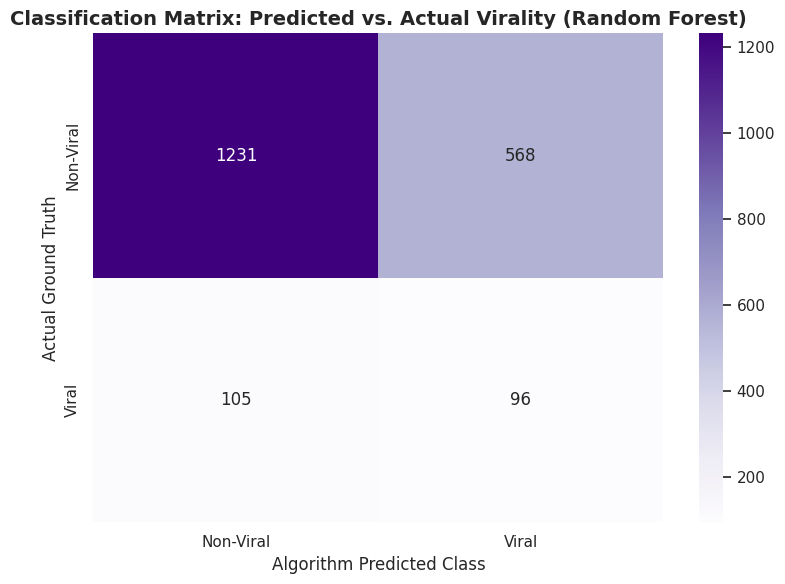


--- 5. ALGORITHMIC FEATURE IMPORTANCE ---


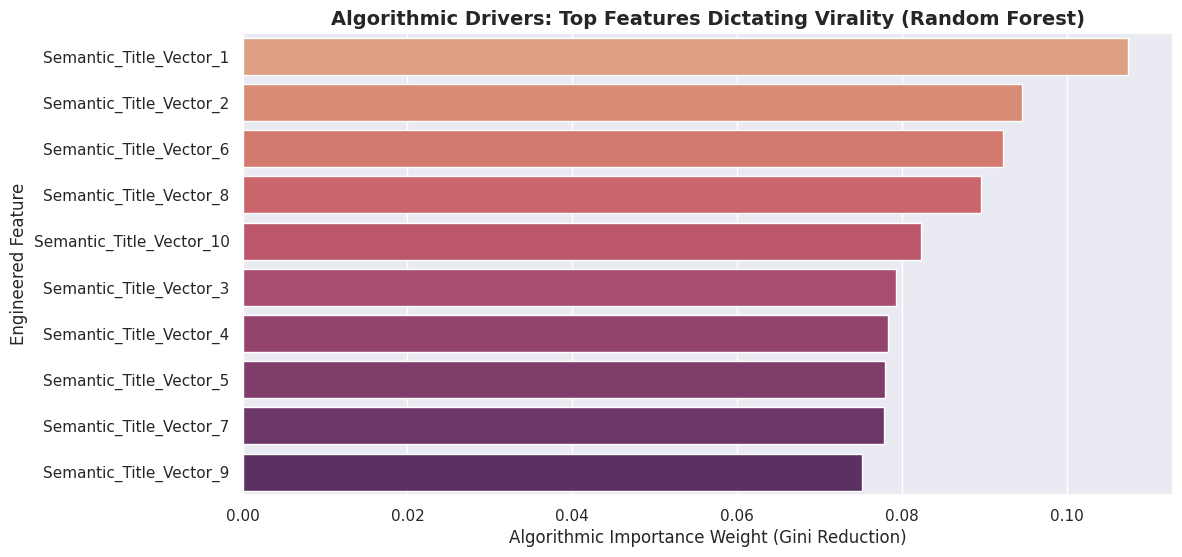

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("--- 1. OUT-OF-SAMPLE DATA SPLITTING ---")
# Split: 80% to train the algorithmic rules, 20% to test true predictive power out-of-sample.
# We use 'stratify=y' to ensure the rare viral posts are distributed evenly between train and test.

X_train, X_test, y_train, y_test = train_test_split(X_adv, y, test_size=0.2, random_state=42, stratify=y)

print(f" Training Set: {len(X_train)} posts")
print(f" Testing Set: {len(X_test)} posts (Strictly Unseen)")


print("\n--- 2. ALGORITHMIC TRAINING (BAGGING VS. BOOSTING) ---")

# 1. Random Forest Classifier
# We use class_weight='balanced' to force the algorithm to care about the rare viral posts.
rf_model = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 2. XGBoost Classifier
# scale_pos_weight is used in XGBoost to handle the massive imbalance between viral (1) and non-viral (0)
scale_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1]) if len(y_train[y_train == 1]) > 0 else 1
xgb_model = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, scale_pos_weight=scale_weight, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

print(" Both Classification Architectures successfully trained.")

print("\n--- 3. OUT-OF-SAMPLE EVALUATION METRICS ---")
rf_preds = rf_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)

def evaluate_classifier(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f" {name} Performance (Predicting 'Viral'):")
    print(f"   -> Accuracy:  {acc * 100:.2f}% (Overall correctness of predictions)")
    print(f"   -> Precision: {prec * 100:.2f}% (When it predicted a post would go viral, how often was it right?)")
    print(f"   -> Recall:    {rec * 100:.2f}% (Out of all the actual viral posts, how many did it successfully catch?)")
    print(f"   -> F1-Score:  {f1 * 100:.2f}% (The harmonic mean of Precision and Recall)")
    return f1

f1_rf = evaluate_classifier("Random Forest", y_test, rf_preds)
print("-" * 40)
f1_xgb = evaluate_classifier("XGBoost", y_test, xgb_preds)

# Selecting the winner based on F1-Score
best_model_name = "XGBoost" if f1_xgb > f1_rf else "Random Forest"
best_preds = xgb_preds if f1_xgb > f1_rf else rf_preds
best_model = xgb_model if f1_xgb > f1_rf else rf_model

print(f"\n The {best_model_name} mathematically outperformed the alternative in tracking rare virality.")

print("\n--- 4. VISUALIZING ALGORITHMIC ACCURACY (CONFUSION MATRIX) ---")
# The Confusion Matrix shows us exactly where the algorithm made its mistakes (False Positives vs False Negatives).

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Non-Viral', 'Viral'],
            yticklabels=['Non-Viral', 'Viral'])
plt.title(f'Classification Matrix: Predicted vs. Actual Virality ({best_model_name})', fontsize=14, fontweight='bold')
plt.xlabel('Algorithm Predicted Class', fontsize=12)
plt.ylabel('Actual Ground Truth', fontsize=12)
plt.tight_layout()
plt.show()

print("\n--- 5. ALGORITHMIC FEATURE IMPORTANCE ---")

importances = pd.Series(best_model.feature_importances_, index=X_adv.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=importances.values, y=importances.index, palette='flare')
plt.title(f'Algorithmic Drivers: Top Features Dictating Virality ({best_model_name})', fontsize=14, fontweight='bold')
plt.xlabel('Algorithmic Importance Weight (Gini Reduction)', fontsize=12)
plt.ylabel('Engineered Feature', fontsize=12)
plt.show()

# Thank You